Customer Churn Prediction
Business problem: Predict which telecom customers are likely to churn, so the company can plan retention strategies.


first load the data from the file, then analyse it using pandas

In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

df = pd.read_csv(os.path.join("..", "data", "TelcoCustomerChurn.csv"))
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


we have total 7043 rows & 21 columns in dataset. now lets check the data types and structures 

In [58]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Total charges is numeric field but has str datatype which may create issues in further analysis since str cant be used to extrtact conclusion from dataset. lets clean it up since eery entry is not null. we can convert it to numeric but there might be avlues which cant be converted to number we can have NaN for thoes. let see if we can convert it.

In [59]:
print("Nulls per column (raw):")
print(df.isnull().sum())

total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nRows where TotalCharges failed to convert to a number:", total_charges_numeric.isna().sum())


Nulls per column (raw):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Rows where TotalCharges failed to convert to a number: 11


looks like there are 11 rows where TotalCharges is blank. Let's see what thoes rows look like.

In [60]:
blank_total_charges = total_charges_numeric.isna()
pd.set_option("display.max_columns", None)
df.loc[blank_total_charges, :]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


total charge for all these rows is empty also tenure seems to be 0. meaning they might be new customers which are yet to be billed. meaning empty string was put in totalcharges to fill that they are not billed yet. we can mark this data to be 0. 

In [61]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["TotalCharges"].isnull().sum()

pd.set_option("display.max_columns", None)
df.loc[blank_total_charges, :]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


let see now if each data row is unique. meaning there are no duplicates. only column i see here is customer id which could be primary/unique key

In [62]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerIDs:", df["customerID"].duplicated().sum())


Fully duplicated rows: 0
Duplicated customerIDs: 0


since there are no duplicated rows each rows is uniq data. we should be able to remove this column it might create issues while training the model since custid might be directly sued to realte  result which we dont want. also idenfiying features here. we  numeric feature totalcharges, monthlycharges, tenure. we have seniorcitizen flag as well rerst of them are enums types (categories). lets identify them one by one using code. churn isnt something we want look at the moment since it the target not feature

In [63]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_numeric = ["SeniorCitizen"]

categorical_features = [
    col for col in df.columns
    if col not in numerical_features + binary_numeric + ["customerID", "Churn"]
]

print("Numerical:", numerical_features)
print("Binary numeric:", binary_numeric)
print("Categorical:", categorical_features)
print("Count check:", len(numerical_features) + len(binary_numeric) + len(categorical_features) + 2, "== 21?")


Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary numeric: ['SeniorCitizen']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count check: 21 == 21?


with use having all the info about feauture now. lets look at the target. like what is the ration of the churn in dataset how many yes and how many nos in count and proportion as well.

In [64]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


here churn is imbalenced around 73% is no and 27 percent to be yes. this means model predicting no for everyone will score 73% and catch no churners. This matters because a model that just predicted "No" for every single customer would still score around 73% accuracy, despite never catching a single actual churner. That makes accuracy alone a misleading measure of success here. Because of this, we need to look at precision, recall, and F1 score when evaluating the model

In [65]:
df_model = df.drop(columns=["customerID"]).copy()
df_model["Churn"] = (df_model["Churn"] == "Yes").astype(int)

df_model["Churn"].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

lets split the data for training using strati_fy we can randomize the datset for both train and test.

In [66]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.2f%%" % (y_train.mean() * 100))
print("Test churn rate:  %.2f%%" % (y_test.mean() * 100))


Train shape: (4930, 19)  Test shape: (2113, 19)
Train churn rate: 26.53%
Test churn rate:  26.55%


churn rate for both sets is almost same so stratify worked. let move onto EDA

Exploratory Data Analysis.
we will do this on complete dataset. we are looking for patterns here about customer behviour using  catogies variables 

1. Churn Distribution
business insight Approximately 1 in 4 customers churn. meaning effort need to targeted towards retaintion

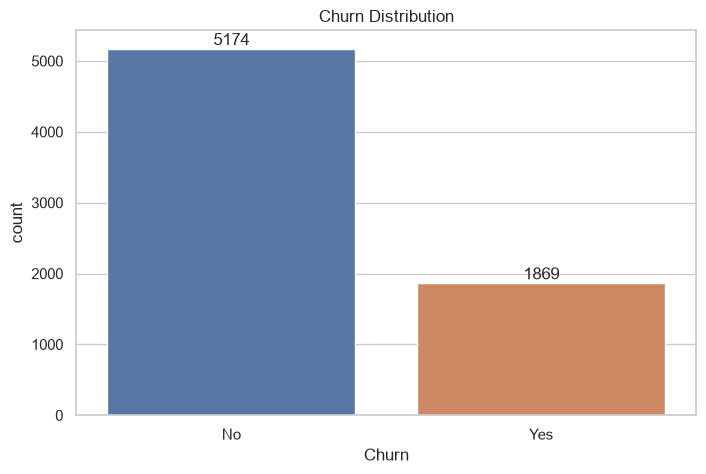

In [67]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

ax.set_title("Churn Distribution")
plt.show()


2.Customer/service characteristics
 Most customers are on a month-to-month contract, not a 1-year or 2-year plan.
 Most customers pay by electronic check, not automatic bank transfer or credit card.
 Most customers use Fiber optic internet, more than DSL

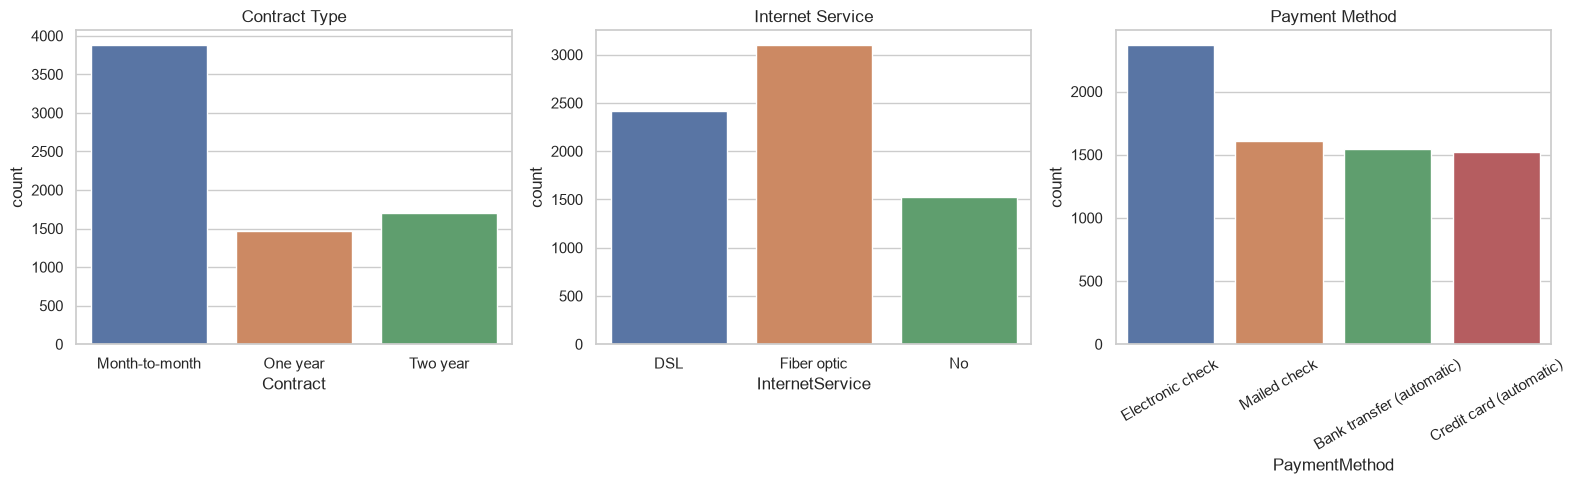

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="Contract", hue="Contract", legend=False, ax=axes[0])
axes[0].set_title("Contract Type")

sns.countplot(data=df, x="InternetService", hue="InternetService", legend=False, ax=axes[1])
axes[1].set_title("Internet Service")

sns.countplot(data=df, x="PaymentMethod", hue="PaymentMethod", legend=False, ax=axes[2])
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_title("Payment Method")

plt.tight_layout()
plt.show()


3 Churn rate by Contract and Internet Service
Customers on month-to-month plans are much more likely to churn around 4 times more than those on one-year contracts and 14 times more than those on two-year contract.

Fiber optic customers also churn about twice as much as DSL customers

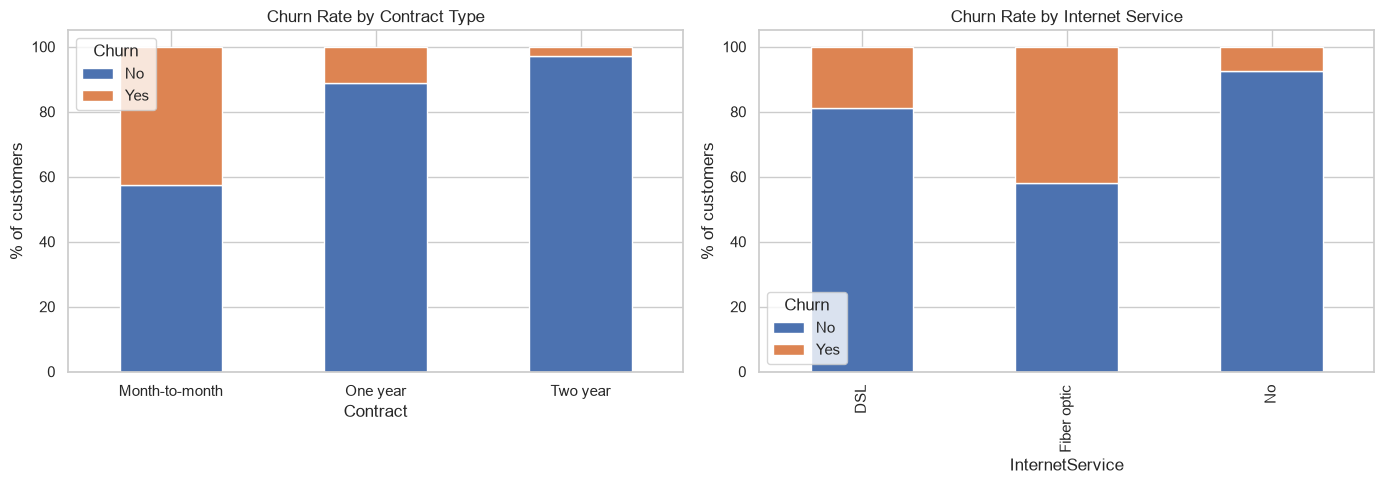

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("% of customers")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].tick_params(axis="x", rotation=0)

internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("% of customers")
axes[1].set_title("Churn Rate by Internet Service")

plt.tight_layout()
plt.show()


4 Churn by Senior Citizen status
Senior customers churn at nearly twice the rate of non-senior customers about 42% compared with 24%.

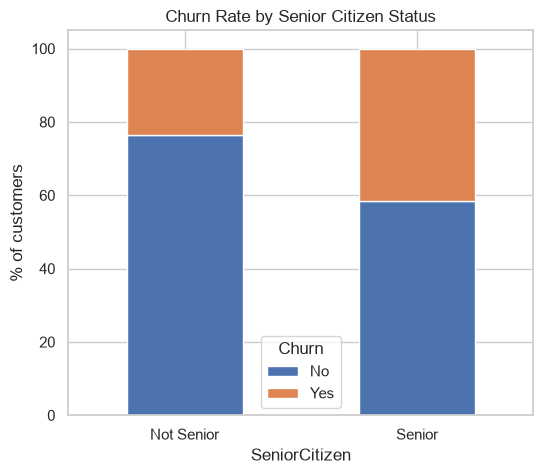

In [70]:
fig, ax = plt.subplots(figsize=(6, 5))

senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
senior_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])

ax.set_xticklabels(["Not Senior", "Senior"], rotation=0)
ax.set_ylabel("% of customers")
ax.set_title("Churn Rate by Senior Citizen Status")
plt.show()


5 Numerical variable distributions by Churn

Customers with low tenure are more likely to churn
Customers with higher monthly charges also tend to churn more
low tenure and high monthly charges means they have low total_charges since they churn early. 

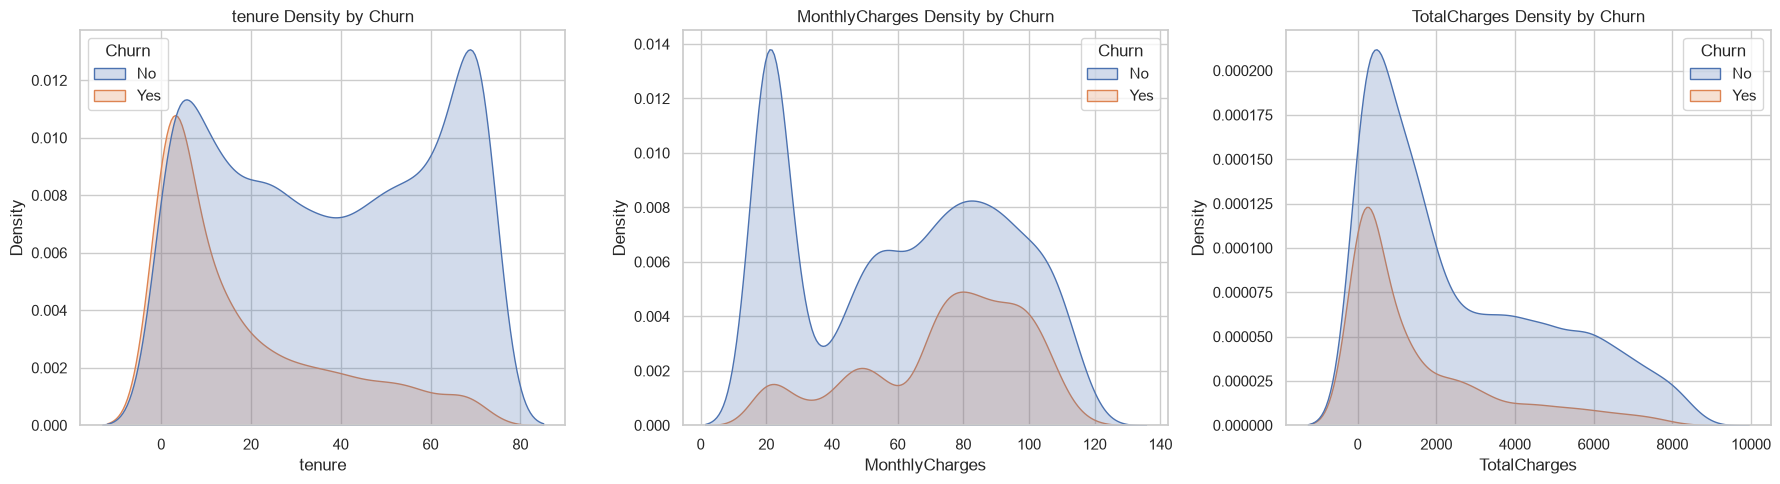

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True,
                palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(f"{col} Density by Churn")

plt.tight_layout()
plt.show()


Feature Engineering 
lets decide on features here based on pattern we have seen earlier visualizations.
lets focus on tenure first

In [72]:
TENURE_BINS = [-1, 6, 12, 24, 48, 60, np.inf]
TENURE_LABELS = ["0-6", "7-12", "13-24", "25-48", "49-60", "61-72"]

df["tenure_group"] = pd.cut(df["tenure"], bins=TENURE_BINS, labels=TENURE_LABELS).astype(str)


In [73]:
tenure_group_churn = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100
tenure_group_churn

Churn,No,Yes
tenure_group,,
0-6,47.062795,52.937205
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-60,85.576923,14.423077
61-72,93.390192,6.609808
7-12,64.113475,35.886525


The tenure value, which ranges from 0 to 72 months, was divided into six groups: 0-6, 7-12, 13-24, 25-48, 49-60, and 61-72 months.The 12 and 24 month points also roughly match the Contract milestones for One year and Two year. The churn rate clearly decreases as tenure_group increases. this insight might be helpful for the model.

In [74]:
addon_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                  "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_add_on_services"] = (df[addon_columns] == "Yes").sum(axis=1)
df[addon_columns + ["num_add_on_services"]].sample(5, random_state=42)
addon_churn = df.groupby("num_add_on_services")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
addon_churn

num_add_on_services
0    21.406039
1    45.755694
2    35.818006
3    27.370304
4    22.300469
5    12.434326
6     5.281690
Name: Churn, dtype: float64

this tells us highere the number of services subscribed by user lower the churn. it is highest at just 1 service. real confussion here is why 0 addon server is lower than one. pattern seem to be broken a bit here. all categories have  values YES, NO, no internet service. meaning everthing here is bound to the internet service column if its no internet service used then next service isnt used. lets check that

In [75]:
zero_addon = df[df["num_add_on_services"] == 0]
zero_addon.groupby("InternetService")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)


InternetService
DSL            41.156463
Fiber optic    60.401003
No              7.404980
Name: Churn, dtype: float64

this tell us people with n internet service churn less that DSL & fiber optics 

In [76]:
one_addon = df[df["num_add_on_services"] == 1]
print(one_addon["InternetService"].value_counts(normalize=True) * 100)
print()
print("Average tenure in this group:", one_addon["tenure"].mean().round(1))
print("Average tenure, whole dataset:", df["tenure"].mean().round(1))


InternetService
Fiber optic    57.039337
DSL            42.960663
Name: proportion, dtype: float64

Average tenure in this group: 16.9
Average tenure, whole dataset: 32.4


There are no No internet service customers in this group. This makes sense because customers without internet cannot have any add-ons marked Yes.

Average tenure is 16.9 months, compared with 32.4 months overall. So, this group mainly consists of newer customers, who are more likely to churn.

Fiber optic (57%) is slightly more common than DSL (43%), and Fiber optic customers also have a higher churn rate

meaning even if we  see bit of off pattern in addon service number we have good insight on what customer churn is with respect to number of the service user subscribes to.

In [77]:
from sklearn.base import BaseEstimator, TransformerMixin

ADD_ON_COLUMNS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                   "TechSupport", "StreamingTV", "StreamingMovies"]

TENURE_BINS = [-1, 6, 12, 24, 48, 60, np.inf]
TENURE_LABELS = ["0-6", "7-12", "13-24", "25-48", "49-60", "61-72"]


class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["tenure_group"] = pd.cut(X["tenure"], bins=TENURE_BINS, labels=TENURE_LABELS).astype(str)
        X["num_add_on_services"] = (X[ADD_ON_COLUMNS] == "Yes").sum(axis=1)
        return X


In [78]:
ChurnFeatureEngineer().fit_transform(X_train.head())[["tenure", "tenure_group", "num_add_on_services"]]


,tenure,tenure_group,num_add_on_services
5557,5,0-6,1
2270,3,0-6,2
6930,3,0-6,0
2257,60,49-60,4
898,12,7-12,4


Model development 
lets add feature engineering and encoding now in sinel pipeline.

In [79]:
CATEGORICAL_COLUMNS = categorical_features + ["tenure_group"]
NUMERIC_COLUMNS = numerical_features + binary_numeric + ["num_add_on_services"]

print("Categorical (to one-hot encode):", CATEGORICAL_COLUMNS)
print("Numeric (passed through as-is):", NUMERIC_COLUMNS)


Categorical (to one-hot encode): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numeric (passed through as-is): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'num_add_on_services']


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLUMNS),
        ("num", "passthrough", NUMERIC_COLUMNS),
    ]
)

pipeline_a = Pipeline(steps=[
    ("feature_engineering", ChurnFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

pipeline_a


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

In [81]:
pipeline_a.fit(X_train, y_train)

train_acc_a = pipeline_a.score(X_train, y_train)
test_acc_a = pipeline_a.score(X_test, y_test)

print(f"Config A — train accuracy: {train_acc_a:.3f} | test accuracy: {test_acc_a:.3f}")
print(f"Tree depth: {pipeline_a.named_steps['classifier'].get_depth()}, "
      f"leaves: {pipeline_a.named_steps['classifier'].get_n_leaves()}")


Config A — train accuracy: 0.998 | test accuracy: 0.731
Tree depth: 23, leaves: 934


almost 98 % training acurracy and 73% on test data. seems like overfitting. may be memorizing rather than learning patterns. we can try with new configurtion with less tree depth

In [82]:
pipeline_b = Pipeline(steps=[
    ("feature_engineering", ChurnFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=40,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

pipeline_b.fit(X_train, y_train)

train_acc_b = pipeline_b.score(X_train, y_train)
test_acc_b = pipeline_b.score(X_test, y_test)

print(f"Config B — train accuracy: {train_acc_b:.3f} | test accuracy: {test_acc_b:.3f}")
print(f"Tree depth: {pipeline_b.named_steps['classifier'].get_depth()}, "
      f"leaves: {pipeline_b.named_steps['classifier'].get_n_leaves()}")


Config B — train accuracy: 0.733 | test accuracy: 0.711
Tree depth: 5, leaves: 31


train and test are alomst same. this is much better. lets compare both model nows pipeline_a and pipeline_b 

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(pipeline, name):
    preds = pipeline.predict(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
    }

comparison = pd.DataFrame([
    evaluate(pipeline_a, "A: Default tree"),
    evaluate(pipeline_b, "B: max_depth=5, balanced"),
]).set_index("Model").round(3)

comparison


,Accuracy,Precision,Recall,F1
Model,,,,
A: Default tree,0.731,0.493,0.499,0.496
"B: max_depth=5, balanced",0.711,0.474,0.799,0.595


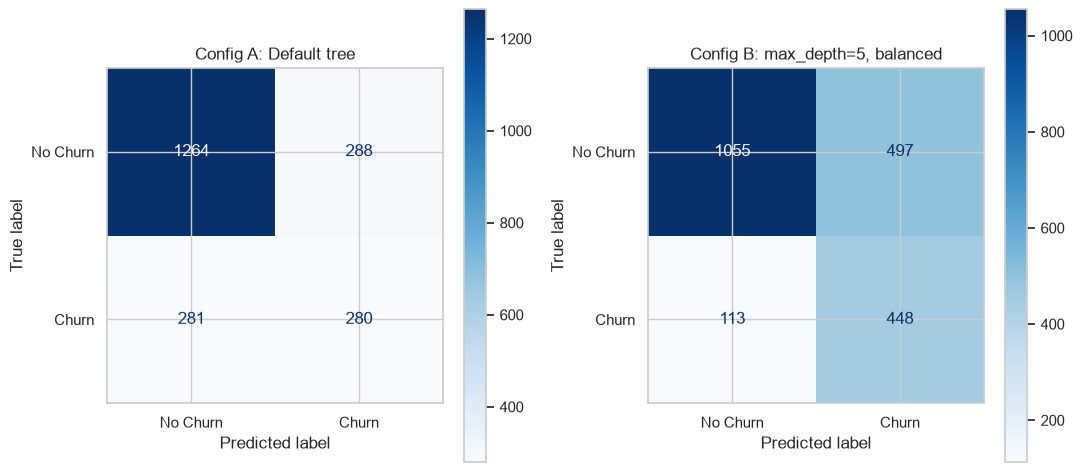

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_estimator(pipeline_a, X_test, y_test,
                                       display_labels=["No Churn", "Churn"],
                                       cmap="Blues", ax=axes[0])
axes[0].set_title("Config A: Default tree")

ConfusionMatrixDisplay.from_estimator(pipeline_b, X_test, y_test,
                                       display_labels=["No Churn", "Churn"],
                                       cmap="Blues", ax=axes[1])
axes[1].set_title("Config B: max_depth=5, balanced")

plt.tight_layout()
plt.show()


pipeline A with defaulkt depth tree
1264 = True Negatives (actually stayed, predicted stayed)
288 = False Positives (actually stayed, predicted churn)
281 = False Negatives (actually churned, predicted stayed)
280 = True Positives (actually churned, predicted churn)

pipeline B with depth 5 
1055 = True Negatives (actually stayed, predicted stayed)
497 = False Positives (actually stayed, predicted churn)
113 = False Negatives (actually churned, predicted stayed)
448 = True Positives (actually churned, predicted churn)

Business Interpretation  Config B

Out of 2,113 test customers, 561 churned and 1,552 stayed.

448 True Positives: The model correctly identified customers who churned, giving the retention team a chance to act.

113 False Negatives: The model missed customers who churned. This is the most costly error because there was no chance to retain them.

497 False Positives: The model flagged customers who stayed. This may lead to some unnecessary calls or offers, but the cost is relatively small.

1,055 True Negatives: The model correctly identified customers who stayed.

Why Config B?

Config B catches 448 churners, compared with 280 for Config A. it has more false positives (497 vs. 288), it misses far fewer actual churners (113 vs. 281).

Precision vs. Recall

For churn prediction, Recall is more important because missing a customer who is about to churn can mean losing their future revenue. A false positive mainly means spending some extra effort on a customer who would have stayed.

So, Config B's approach of accepting more false alarms to catch more churners makes sense for a retention use case.

Model Interpretation

We inspect the final model (Config B) to understand which features drive its churn
predictions both numerically (feature importances) and visually (the tree structure itself).


In [85]:
ohe = pipeline_b.named_steps["preprocessing"].named_transformers_["cat"]
encoded_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_COLUMNS)) + NUMERIC_COLUMNS

importances = pd.Series(
    pipeline_b.named_steps["classifier"].feature_importances_,
    index=encoded_feature_names
).sort_values(ascending=False)

importances.head(15)


Contract_Month-to-month            0.611748
tenure                             0.112360
InternetService_Fiber optic        0.101879
MonthlyCharges                     0.051217
TotalCharges                       0.030989
OnlineSecurity_No                  0.018647
StreamingTV_No internet service    0.016568
TechSupport_No                     0.014839
PaymentMethod_Electronic check     0.014388
StreamingMovies_Yes                0.006684
Contract_One year                  0.005959
Dependents_No                      0.005140
PaymentMethod_Mailed check         0.005125
OnlineBackup_No                    0.002374
gender_Male                        0.001717
dtype: float64

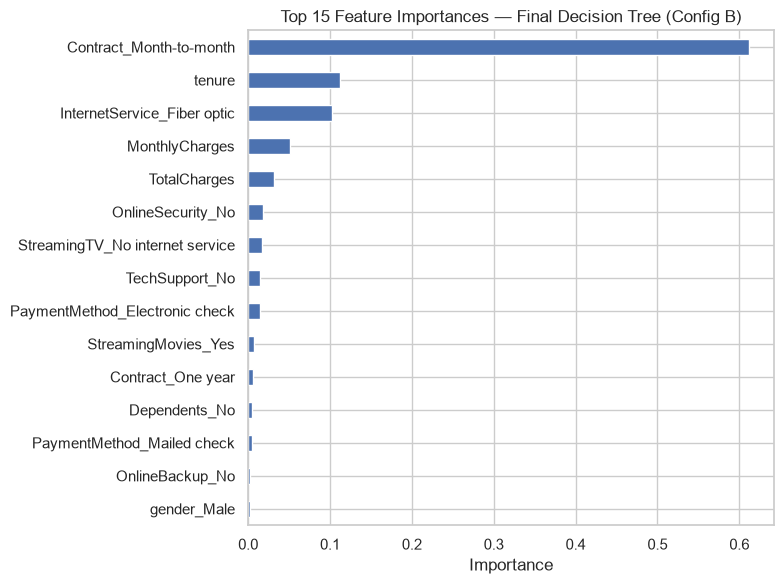

In [86]:
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Feature Importances — Final Decision Tree (Config B)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


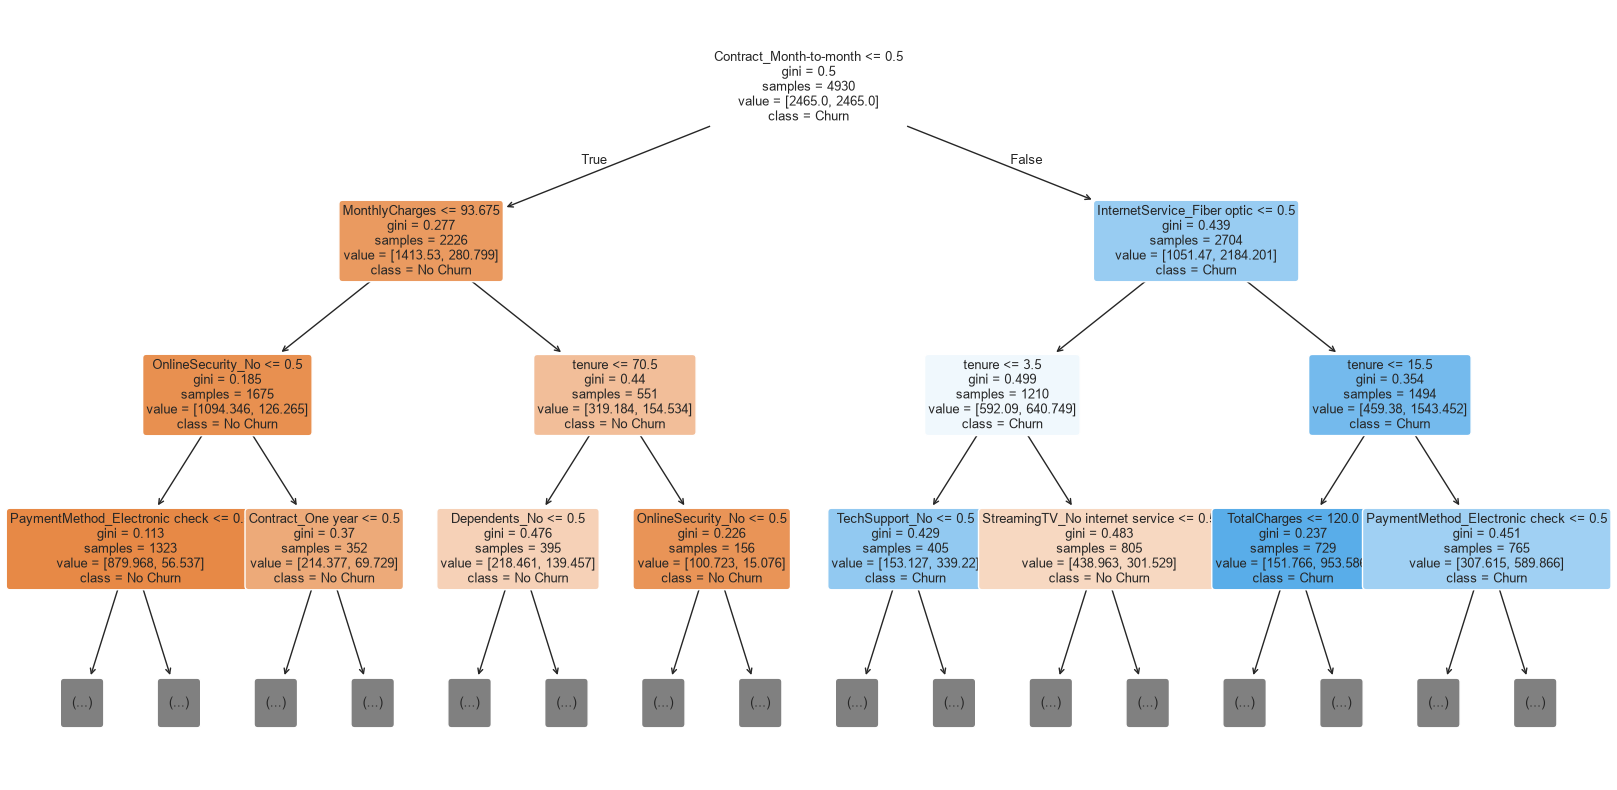

In [87]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    pipeline_b.named_steps["classifier"],
    max_depth=3,
    feature_names=encoded_feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.show()


Lets store the model now 

In [88]:
import joblib
import os

MODEL_DIR = os.path.join("..", "model")
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "my_churn_model.pkl")
joblib.dump(pipeline_b, model_path)

print("Saved to:", model_path)


Saved to: ..\model\my_churn_model.pkl
